# Hands-on Exercise: Structured Invoice Extraction

Fill in the `TODO(...)` blanks to complete the notebook.

In [1]:
def TODO(todo: str = "Fill the blank"):
    raise ValueError(todo)

In [2]:
import os
from openai import OpenAI
import pydantic
import random
from PIL import Image

from ie_course.image import encode_image

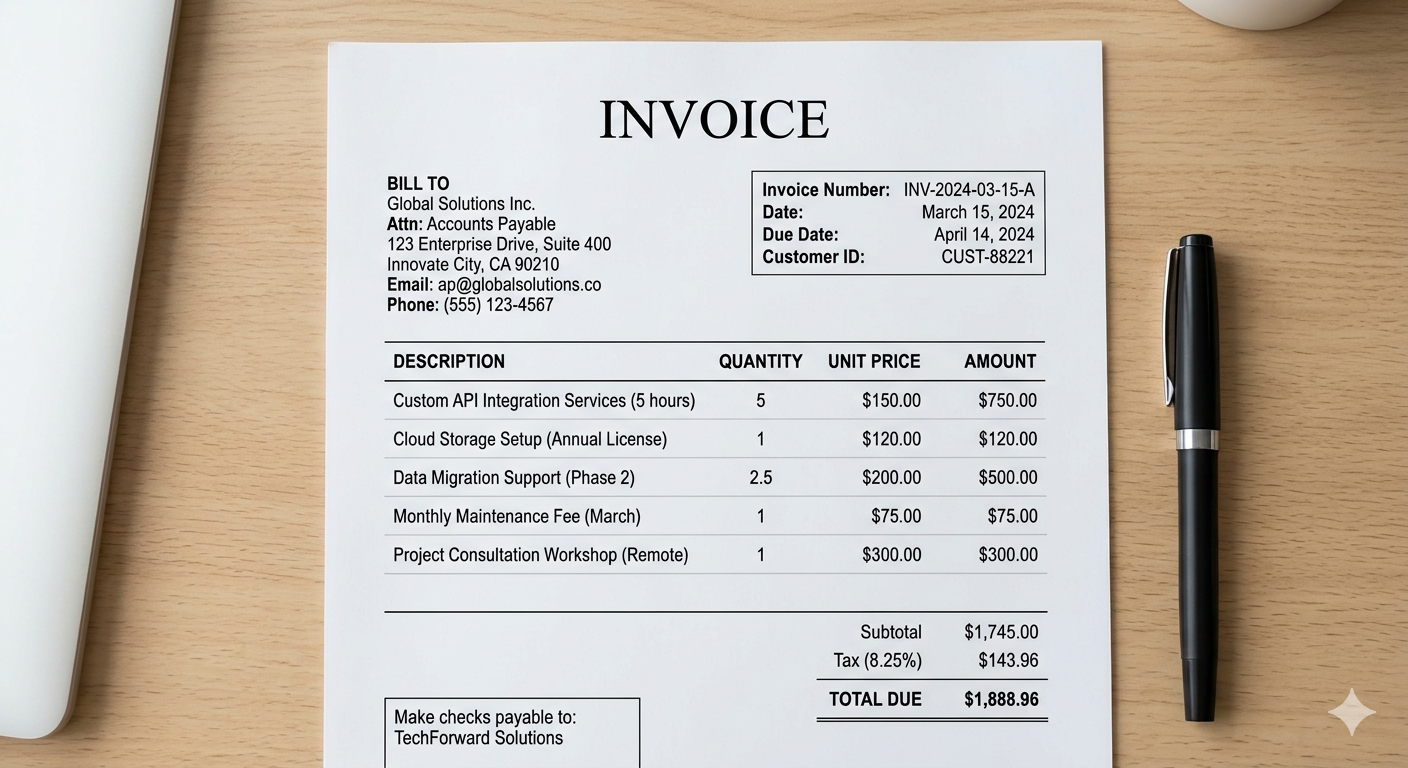

In [3]:
Image.open("../../data/gemini_generated_invoice.png")

In [4]:
img_bytes = encode_image("../../data/gemini_generated_invoice.png")

### Exercise 1
Load the API key from the environment or just type it here.

In [5]:
# os.environ["CHATAI_API_KEY"]
key = os.environ["CHATAI_API_KEY"]
url = "https://chat-ai.academiccloud.de/v1"

### Exercise 2
Create the API client.

In [6]:
client = OpenAI(base_url=url, api_key=key)

### Exercise 3
Choose a model.

In [8]:
[x.id for x in client.models.list()]

['qwen3-coder-30b-a3b-instruct',
 'glm-4.7',
 'qwen3.6-35b-a3b',
 'apertus-70b-instruct-2509',
 'qwen3-omni-30b-a3b-instruct',
 'devstral-2-123b-instruct-2512',
 'internvl3.5-30b-a3b',
 'qwen3.5-122b-a10b',
 'qwen3.5-397b-a17b',
 'gemma-4-31b-it',
 'mistral-large-3-675b-instruct-2512',
 'meta-llama-3.1-8b-instruct',
 'openai-gpt-oss-120b',
 'qwen3-30b-a3b-instruct-2507',
 'medgemma-27b-it',
 'deepseek-r1-distill-llama-70b',
 'teuken-7b-instruct-research']

In [9]:
model = 'qwen3.5-122b-a10b'

### Exercise 4
Insert the image data URL.

In [10]:
messages = [
    {
        "role": "system",
        "content": """
        Du extrahierst Informationen wie Rechnungspositionen und Rechnungsbeträge aus gescannten deutschsprachigen 
        Rechnungen und Gutschriften.
        """
    },
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": "Extract ONLY the total amount due from this invoice. Return only the number."
            },
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/png;base64,{img_bytes}"
                }
            }
        ]
    }
]


In [11]:
invoice_schema = {
    "type": "object",
    "properties": {
        "vendor_name":    {"type": "string"},
        "buyer_name":    {"type": "string"},
        "invoice_number": {"type": "string"},
        "issue_date":     {"type": "string", "description": "ISO 8601 date, e.g. 2024-09-15"},
        "currency":       {"type": "string", "description": "3-letter ISO code"},
        "status": {
            "type": "string",
            "enum": ["paid", "unpaid", "partially_paid", "unknown", None]
        },
        "line_items": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "description": {"type": "string"},
                    "quantity":    {"type": "integer"},
                    "unit_price":  {"type": "number"}
                },
                "required": ["description", "quantity", "unit_price"],
                "additionalProperties": False
            }
        },
        "total_amount":   {"type": "number"},
        "purchase_order": {"type": ["string", "null"]}
    },
    "required": [
        "vendor_name", "buyer_name", "invoice_number", "issue_date", "currency",
        "status", "line_items", "total_amount", "purchase_order"
    ],
    "additionalProperties": False
}

### Exercise 5
Enable JSON schema output.

In [12]:
response = client.chat.completions.create(
    model=model,
    messages=messages,
    temperature=0,
    response_format={
        "type": "json_schema",
        "json_schema": {
            "name": "ExtractionSchema",
            "schema": invoice_schema,
            "strict": True, 
        }
    },
)

In [13]:
print(response.choices[0].message.content)

{
  "vendor_name": "TechForward Solutions",
  "buyer_name": "Global Solutions Inc.",
  "invoice_number": "INV-2024-03-15-A",
  "issue_date": "2024-03-15",
  "currency": "USD",
  "status": "paid",
  "line_items": [
    {
      "description": "Custom API Integration Services (5 hours)",
      "quantity": 5,
      "unit_price": 150.00
    },
    {
      "description": "Cloud Storage Setup (Annual License)",
      "quantity": 1,
      "unit_price": 120.00
    },
    {
      "description": "Data Migration Support (Phase 2)",
      "quantity": 2,
      "unit_price": 200.00
    },
    {
      "description": "Monthly Maintenance Fee (March)",
      "quantity": 1,
      "unit_price": 75.00
    },
    {
      "description": "Project Consultation Workshop (Remote)",
      "quantity": 1,
      "unit_price": 300.00
    }
  ],
  "total_amount": 1888.96,
  "purchase_order": null
}
